# English dataset analysis

This notebook produces a lightweight, thesis-oriented description of the authenticated ED archives used by TVA. It covers archive identity, fold composition, writer separation, label and sequence lengths, sampled channel statistics, and the behavior of the two already-frozen IAM-derived tokenizers.

In [1]:
from collections import Counter
import hashlib
import io
import json
import os
from pathlib import Path
import unicodedata
import zipfile

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

from tva.dataset.ed import (
    ED_ARCHIVE_SHA256,
    ED_ARCHIVE_STEM,
    ED_NUM_CHANNELS,
    ED_NUM_FOLDS,
    ED_SAMPLE_RATE,
)
from tva.handwriting_bigram_tokenizer import (
    GreedyHandwritingBigramTokenizer,
    GreedyLinguisticBigramTokenizer,
)

REPO_ROOT = Path.cwd()
DATASET_DIR = Path(
    os.environ.get(
        'TVA_ED_DATASET_DIR',
        '/mnt/c/Users/Ali/Downloads/ed-dataset',
    )
).expanduser()
ARCHIVE_PATHS = {
    distribution: DATASET_DIR / f'{stem}.zip'
    for distribution, stem in ED_ARCHIVE_STEM.items()
}

print(f'Repository: {REPO_ROOT}')
print(f'Dataset directory: {DATASET_DIR}')
for distribution, path in ARCHIVE_PATHS.items():
    if not path.is_file():
        raise FileNotFoundError(f'Missing {distribution.upper()} archive: {path}')

Repository: /home/artellisys/TVA
Dataset directory: /mnt/c/Users/Ali/Downloads/ed-dataset


In [2]:
def sha256(path):
    digest = hashlib.sha256()
    with path.open('rb') as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b''):
            digest.update(block)
    return digest.hexdigest()


def load_archive(distribution, path):
    digest = sha256(path)
    expected = ED_ARCHIVE_SHA256[distribution]
    if digest != expected:
        raise ValueError(
            f'{distribution.upper()} SHA-256 mismatch: {digest}'
        )
    stem = ED_ARCHIVE_STEM[distribution]
    with zipfile.ZipFile(path) as archive:
        return {
            'digest': digest,
            'annotations': json.loads(
                archive.read(f'{stem}/annotations.json')
            ),
            'train': json.loads(archive.read(f'{stem}/train.json')),
            'val': json.loads(archive.read(f'{stem}/val.json')),
            'length_summary': json.loads(
                archive.read(f'{stem}/statistics/statistic_length.json')
            ),
        }


def markdown_table(rows, columns):
    def clean(value):
        return str(value).replace('|', '\|')

    lines = [
        '| ' + ' | '.join(columns) + ' |',
        '| ' + ' | '.join(['---'] * len(columns)) + ' |',
    ]
    for row in rows:
        lines.append('| ' + ' | '.join(clean(row[c]) for c in columns) + ' |')
    display(Markdown('\n'.join(lines)))


archives = {
    distribution: load_archive(distribution, path)
    for distribution, path in ARCHIVE_PATHS.items()
}

## 1. Archive identity and canonical records

The two archives package different fold definitions over the same canonical recordings. This cell verifies that identity instead of assuming it.

In [3]:
record_maps = {}
overview_rows = []
for distribution, payload in archives.items():
    records = payload['annotations']['annotations']
    record_maps[distribution] = {
        record['id']: (
            unicodedata.normalize('NFC', record['label']),
            record['id_writer'],
            record['filename'],
        )
        for record in records
    }
    info = payload['annotations']['info']
    overview_rows.append({
        'archive': distribution.upper(),
        'SHA-256': payload['digest'],
        'recordings': len(records),
        'writers': len({r['id_writer'] for r in records}),
        'channels': info['num_channel'],
        'sample rate': f"{info['rate_sample_target']} Hz",
    })

if record_maps['wd'] != record_maps['wi']:
    raise ValueError('WD and WI do not contain identical canonical records')

markdown_table(
    overview_rows,
    ['archive', 'SHA-256', 'recordings', 'writers', 'channels', 'sample rate'],
)
print('Canonical WD/WI record identity: verified')

| archive | SHA-256 | recordings | writers | channels | sample rate |
| --- | --- | --- | --- | --- | --- |
| WD | edaf78b0f422f719bbb13153249a5a6667a814d6f5a8d7d0d2ba02535ae55a3e | 2550 | 102 | 7 | 100 Hz |
| WI | 0ba1b8e5d53c7208bbdc4a43cfb701ed6a1d27be382a23ba0aaade8cb3283304 | 2550 | 102 | 7 | 100 Hz |

Canonical WD/WI record identity: verified


## 2. Fold sizes and writer separation

Writer-dependent folds may share writers between training and validation; writer-independent folds must not. Sample IDs must remain disjoint within every fold.

| split | fold | train samples | val samples | train writers | val writers | writer overlap |
| --- | --- | --- | --- | --- | --- | --- |
| WD | 0 | 2047 | 503 | 102 | 102 | 102 |
| WD | 1 | 2039 | 511 | 102 | 101 | 101 |
| WD | 2 | 2036 | 514 | 102 | 102 | 102 |
| WD | 3 | 2019 | 531 | 102 | 102 | 102 |
| WD | 4 | 2059 | 491 | 102 | 102 | 102 |
| WI | 0 | 2025 | 525 | 81 | 21 | 0 |
| WI | 1 | 2025 | 525 | 81 | 21 | 0 |
| WI | 2 | 2050 | 500 | 82 | 20 | 0 |
| WI | 3 | 2050 | 500 | 82 | 20 | 0 |
| WI | 4 | 2050 | 500 | 82 | 20 | 0 |

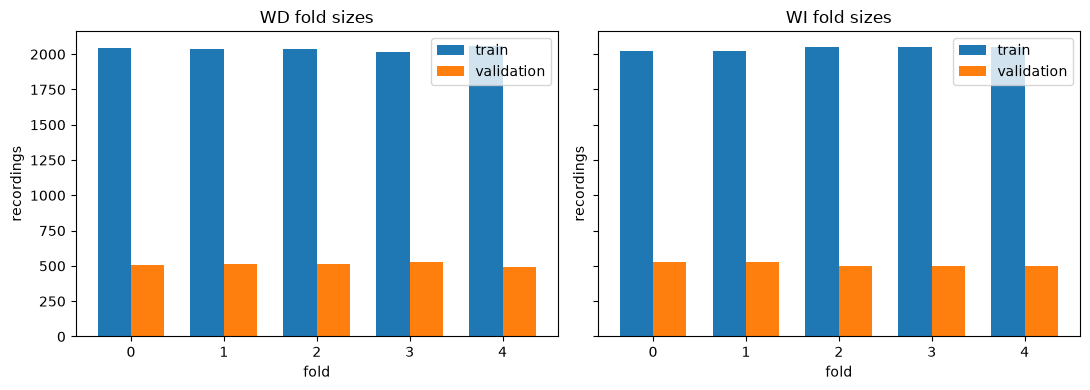

In [4]:
fold_rows = []
for distribution, payload in archives.items():
    for fold in range(ED_NUM_FOLDS):
        train = payload['train']['annotations'][str(fold)]
        val = payload['val']['annotations'][str(fold)]
        train_ids = {record['id'] for record in train}
        val_ids = {record['id'] for record in val}
        train_writers = {record['id_writer'] for record in train}
        val_writers = {record['id_writer'] for record in val}
        if train_ids & val_ids:
            raise ValueError(f'{distribution} fold {fold} leaks sample IDs')
        if train_ids | val_ids != set(record_maps[distribution]):
            raise ValueError(f'{distribution} fold {fold} is incomplete')
        writer_overlap = len(train_writers & val_writers)
        if distribution == 'wi' and writer_overlap:
            raise ValueError(f'WI fold {fold} leaks writers')
        fold_rows.append({
            'split': distribution.upper(),
            'fold': fold,
            'train samples': len(train),
            'val samples': len(val),
            'train writers': len(train_writers),
            'val writers': len(val_writers),
            'writer overlap': writer_overlap,
        })

markdown_table(
    fold_rows,
    [
        'split', 'fold', 'train samples', 'val samples',
        'train writers', 'val writers', 'writer overlap',
    ],
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for axis, distribution in zip(axes, ('WD', 'WI')):
    rows = [row for row in fold_rows if row['split'] == distribution]
    folds = np.arange(ED_NUM_FOLDS)
    axis.bar(folds - 0.18, [r['train samples'] for r in rows], 0.36, label='train')
    axis.bar(folds + 0.18, [r['val samples'] for r in rows], 0.36, label='validation')
    axis.set(title=f'{distribution} fold sizes', xlabel='fold', ylabel='recordings')
    axis.set_xticks(folds)
    axis.legend()
plt.tight_layout()
plt.show()

## 3. Label characteristics

The label inventory is described after tokenizer freeze. Character frequencies shown here are not inputs to vocabulary construction.

In [5]:
records = archives['wd']['annotations']['annotations']
labels = [unicodedata.normalize('NFC', r['label']) for r in records]
character_lengths = np.array([len(label) for label in labels])
word_lengths = np.array([len(label.split()) for label in labels])
character_counts = Counter(''.join(labels))

label_rows = [{
    'recordings': len(labels),
    'unique labels': len(set(labels)),
    'characters mean': f'{character_lengths.mean():.2f}',
    'characters median': f'{np.median(character_lengths):.0f}',
    'characters range': f'{character_lengths.min()}–{character_lengths.max()}',
    'words mean': f'{word_lengths.mean():.2f}',
    'words median': f'{np.median(word_lengths):.0f}',
}]
markdown_table(label_rows, list(label_rows[0]))

frequent_rows = [
    {'character': repr(character), 'count': count}
    for character, count in character_counts.most_common(15)
]
display(Markdown('**Fifteen most frequent characters (descriptive only)**'))
markdown_table(frequent_rows, ['character', 'count'])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(character_lengths, bins=30, edgecolor='white')
axes[0].set(title='Label length', xlabel='characters', ylabel='recordings')
axes[1].hist(word_lengths, bins=np.arange(word_lengths.max() + 2) - 0.5, edgecolor='white')
axes[1].set(title='Sentence length', xlabel='words', ylabel='recordings')
plt.tight_layout()
plt.show()

| recordings | unique labels | characters mean | characters median | characters range | words mean | words median |
| --- | --- | --- | --- | --- | --- | --- |
| 2550 | 501 | 41.60 | 43 | 10–63 | 7.65 | 8 |

**Fifteen most frequent characters (descriptive only)**

| character | count |
| --- | --- |
| ' ' | 16979 |
| 'e' | 8875 |
| 't' | 6163 |
| 'o' | 5664 |
| 'a' | 5596 |
| 'i' | 4860 |
| 's' | 4717 |
| 'n' | 4688 |
| 'r' | 4176 |
| 'h' | 3035 |
| 'l' | 2879 |
| 'd' | 2271 |
| 'u' | 2250 |
| '.' | 1813 |
| 'c' | 1713 |

## 4. Sequence lengths and sampled channel statistics

The global sequence-length summary is read from the authenticated archive. Channel statistics are computed from a deterministic sample of 128 recordings and must be labelled as sample estimates, not population statistics. Archive channel indices are reported without guessing physical axis names.

| minimum samples | median samples | mean samples | maximum samples | mean duration |
| --- | --- | --- | --- | --- |
| 393 | 2055.0 | 2137.65 | 7314 | 21.38 s |

| archive column | source channel index | mean | std | minimum | maximum |
| --- | --- | --- | --- | --- | --- |
| 0 | 3 | -0.74427 | 3.90355 | -19.61761 | 19.61401 |
| 1 | 4 | -8.07442 | 1.36715 | -19.61401 | 13.72346 |
| 2 | 5 | 0.07550 | 4.48842 | -19.61761 | 19.61401 |
| 3 | 6 | 0.03328 | 23.28699 | -499.90921 | 496.32263 |
| 4 | 7 | -0.90696 | 48.24855 | -500.37115 | 499.93896 |
| 5 | 8 | -0.07217 | 23.05563 | -444.65778 | 499.93896 |
| 6 | 12 | 0.74211 | 0.87116 | 0.00000 | 8.44643 |

Deterministic channel sample: 128 recordings, seed 42


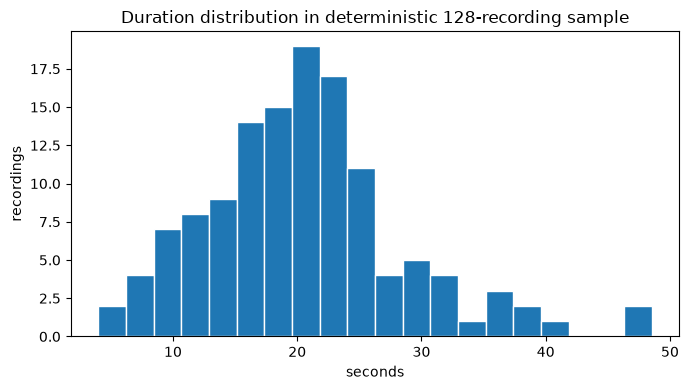

In [6]:
length_summary = archives['wd']['length_summary']
length_row = {
    'minimum samples': length_summary['min'],
    'median samples': length_summary['median'],
    'mean samples': f"{length_summary['mean']:.2f}",
    'maximum samples': length_summary['max'],
    'mean duration': f"{length_summary['mean'] / ED_SAMPLE_RATE:.2f} s",
}
markdown_table([length_row], list(length_row))

rng = np.random.default_rng(42)
sample_indices = np.sort(rng.choice(len(records), size=128, replace=False))
sample_sequences = []
stem = ED_ARCHIVE_STEM['wd']
with zipfile.ZipFile(ARCHIVE_PATHS['wd']) as archive:
    for index in sample_indices:
        record = records[int(index)]
        content = archive.read(f"{stem}/{record['filename']}")
        sequence = np.loadtxt(
            io.BytesIO(content), delimiter=';', dtype=np.float32
        )
        if sequence.ndim != 2 or sequence.shape[1] != ED_NUM_CHANNELS:
            raise ValueError(f"Invalid signal shape for {record['id']}")
        sample_sequences.append(sequence)

sample_values = np.concatenate(sample_sequences, axis=0)
channel_indices = archives['wd']['annotations']['info']['idxs_channel']
channel_rows = []
for offset, source_index in enumerate(channel_indices):
    values = sample_values[:, offset]
    channel_rows.append({
        'archive column': offset,
        'source channel index': source_index,
        'mean': f'{values.mean():.5f}',
        'std': f'{values.std():.5f}',
        'minimum': f'{values.min():.5f}',
        'maximum': f'{values.max():.5f}',
    })
markdown_table(channel_rows, list(channel_rows[0]))
print(f'Deterministic channel sample: {len(sample_sequences)} recordings, seed 42')

sample_durations = np.array([len(sequence) for sequence in sample_sequences]) / ED_SAMPLE_RATE
plt.figure(figsize=(7, 4))
plt.hist(sample_durations, bins=20, edgecolor='white')
plt.title('Duration distribution in deterministic 128-recording sample')
plt.xlabel('seconds')
plt.ylabel('recordings')
plt.tight_layout()
plt.show()

## 5. Frozen-tokenizer coverage and target compression

Both vocabularies were frozen from IAM before ED evaluation. This cell audits lossless round trips and measures the resulting target lengths; it does not optimize either vocabulary on ED.

2026-09-25 12:25:23.131 | INFO     | tva.handwriting_bigram_tokenizer:load:382 - GreedyHandwritingBigramTokenizer is loaded from /home/artellisys/TVA/artifacts/tokenizers/ed_iam_handwriting_bigram_greedy_v1.json.
2026-09-25 12:25:23.208 | INFO     | tva.handwriting_bigram_tokenizer:load:485 - GreedyLinguisticBigramTokenizer is loaded from /home/artellisys/TVA/artifacts/tokenizers/ed_iam_linguistic_bigram_greedy_v1.json.


| tokenizer | output classes | total targets | mean targets/label | bigrams emitted | target reduction | round-trip failures | blank IDs |
| --- | --- | --- | --- | --- | --- | --- | --- |
| handwriting-aware | 224 | 85153 | 33.39 | 20934 | 19.73% | 0 | 0 |
| linguistic | 224 | 79078 | 31.01 | 27009 | 25.46% | 0 | 0 |

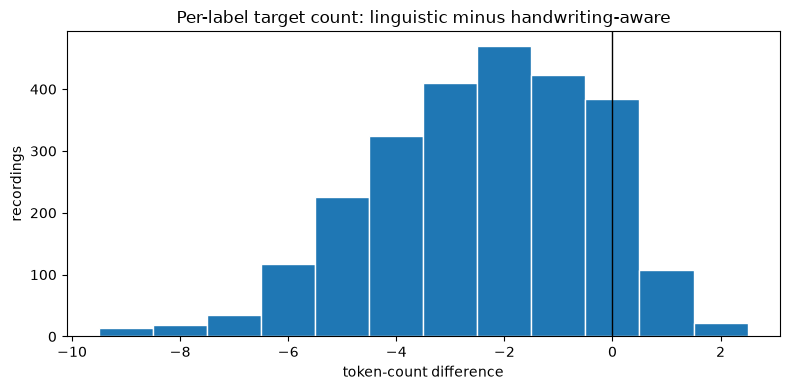

In [7]:
tokenizer_specs = {
    'handwriting-aware': (
        GreedyHandwritingBigramTokenizer,
        REPO_ROOT / 'artifacts/tokenizers/ed_iam_handwriting_bigram_greedy_v1.json',
    ),
    'linguistic': (
        GreedyLinguisticBigramTokenizer,
        REPO_ROOT / 'artifacts/tokenizers/ed_iam_linguistic_bigram_greedy_v1.json',
    ),
}

token_lengths = {}
tokenizer_rows = []
character_total = sum(map(len, labels))
for name, (tokenizer_class, artifact) in tokenizer_specs.items():
    tokenizer = tokenizer_class()
    tokenizer.load(artifact)
    lengths = []
    for label in labels:
        ids = tokenizer.encode(label)
        if not ids or 0 in ids:
            raise ValueError(f'{name} emitted an empty/blank target')
        if tokenizer.decode(ids) != label:
            raise ValueError(f'{name} failed round trip for {label!r}')
        lengths.append(len(ids))
    token_lengths[name] = np.array(lengths)
    token_total = sum(lengths)
    tokenizer_rows.append({
        'tokenizer': name,
        'output classes': tokenizer.size,
        'total targets': token_total,
        'mean targets/label': f'{np.mean(lengths):.2f}',
        'bigrams emitted': character_total - token_total,
        'target reduction': f'{100 * (character_total - token_total) / character_total:.2f}%',
        'round-trip failures': 0,
        'blank IDs': 0,
    })

markdown_table(tokenizer_rows, list(tokenizer_rows[0]))
delta = token_lengths['linguistic'] - token_lengths['handwriting-aware']
plt.figure(figsize=(8, 4))
bins = np.arange(delta.min(), delta.max() + 2) - 0.5
plt.hist(delta, bins=bins, edgecolor='white')
plt.axvline(0, color='black', linewidth=1)
plt.title('Per-label target count: linguistic minus handwriting-aware')
plt.xlabel('token-count difference')
plt.ylabel('recordings')
plt.tight_layout()
plt.show()

## Interpretation checklist

- WD and WI contain the same canonical recordings but impose different fold membership and writer-overlap constraints.
- Sequence lengths are much longer than the earlier OnHW word inputs, which motivates explicit memory and runtime measurements.
- Both frozen tokenizers must encode every label losslessly without emitting CTC blank ID 0.
- Different target counts are an inherent part of the vocabulary treatment, not evidence that one recognizer is better. Recognition conclusions must come from matched five-fold CER/WER results.
- Do not revise tokenizer contents after reviewing this notebook; doing so would invalidate the pre-freeze leakage boundary.